In [1]:
import cv2
import helperFuns as helper
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from scipy import stats

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENCV_NUM_THREADS"] = "1"

In [2]:
def center_image(img_test: np.ndarray, img_ref: np.ndarray, perc_jitter: int) -> np.ndarray:
    
    backgroundTest = stats.mode(img_test.flatten())[0]
    binary = img_test != backgroundTest
    binary = binary.astype(np.uint8) * 255  # Convert boolean to uint8 for display

    # Calculate moments
    M = cv2.moments(binary)

    if M["m00"] != 0:
        cX_old = int(M["m10"] / M["m00"])
        cY_old = int(M["m01"] / M["m00"])
    else:
        raise ValueError("The test image is empty or has no foreground pixels.")
    
    # Threshold the image to binary (you may need to adjust the threshold)
    # If img_ref exists, use it to find the centroid
    if img_ref is None:
        h, w = img_test.shape
        cX_new, cY_new = w // 2, h // 2  # Center of the image
    else:
        backgroundRef = stats.mode(img_ref.flatten())[0]
        binary = img_ref != backgroundRef
        binary = binary.astype(np.uint8) * 255  # Convert boolean to uint8 for display

        # Calculate moments
        M = cv2.moments(binary)

        if M["m00"] != 0:
            cX_new = int(M["m10"] / M["m00"])
            cY_new = int(M["m01"] / M["m00"])
        else:
            raise ValueError("The reference image is empty or has no foreground pixels.")

    # Calculate the translation needed to center the image
    h, w = img_test.shape
    translation_x = cX_new - cX_old
    translation_y = cY_new - cY_old

    # Calculate range of centering jitter based on percent of image size
    jitter_x = int(w * perc_jitter / 100)
    jitter_y = int(h * perc_jitter / 100)

    # Randomly select a jitter value within the specified range
    jitter_x = np.random.randint(-jitter_x, jitter_x + 1)
    jitter_y = np.random.randint(-jitter_y, jitter_y + 1)

    # Update the translation values with jitter
    translation_x += jitter_x
    translation_y += jitter_y

    # Create a translation matrix
    translation_matrix = np.float32([[1, 0, translation_x], [0, 1, translation_y]])
    # Apply the translation to the test image
    img_test_centered = cv2.warpAffine(img_test, translation_matrix, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=int(backgroundTest))

    return img_test_centered

In [3]:
projectpath = '/mnt/DataDrive3/emeyer/TreeShrewObjectRecognition/'
taskName = 'Camel_v2_test_nn' #'Camel_v2_test_nn' 'Camel_Rhino_test_nn' , 'Camel_v2_test_nn', 'Camel_background_matrix'
imgPath = f'{projectpath}stimulusSets/{taskName}/original/'

In [4]:
taskName = 'Camel_v2_test_nn' #'Camel_v2_test_nn' 'Camel_Rhino_test_nn' , 'Camel_v2_test_nn', 'Camel_background_matrix'
getDataPath = projectpath + '4_treeShrewBehavior/behaviorData/'
train_targ_idx, train_dist_idx, _, targ_idx, dist_idx = helper.get_train_targdist_data(getDataPath,taskName)
test_targ_idx = np.setdiff1d(targ_idx, train_targ_idx)
test_dist_idx = np.setdiff1d(dist_idx, train_dist_idx)

In [16]:
def process_row(targ, dist, Mdl, jj, imgPath, ref_img):
    cv2.setNumThreads(1) 

    if Mdl is None:
    # Extract images with indexes in train_targ_idx and train_dist_idx
        train_targets = []
        for t_idx in train_targ_idx:
            timg = cv2.imread(f'{imgPath}camel_{int(t_idx)}.png', cv2.IMREAD_GRAYSCALE)
            timg = center_image(timg, img_ref, jj)
            train_targets.append(timg)
        train_targets = np.array(train_targets)

        train_distractors = []
        for d_idx in train_dist_idx:
            dimg = cv2.imread(f'{imgPath}wrench_{int(d_idx)}.png', cv2.IMREAD_GRAYSCALE)
            dimg = center_image(dimg, img_ref, jj)
            train_distractors.append(dimg)
        train_distractors = np.array(train_distractors)

        train_set = np.concatenate((train_targets, train_distractors), axis=0)
        train_set = train_set.reshape(len(train_set), -1)

        train_labels = np.concatenate((np.ones(len(train_targets)), np.zeros(len(train_distractors))), axis=0)

        Mdl = make_pipeline(StandardScaler(), LinearSVC(random_state=42))
        Mdl.fit(train_set, train_labels)

    targ_img = cv2.imread(f'{imgPath}camel_{int(targ)}.png',  cv2.IMREAD_GRAYSCALE)
    dist_img = cv2.imread(f'{imgPath}wrench_{int(dist)}.png', cv2.IMREAD_GRAYSCALE)
    targ_img_centered = center_image(targ_img, ref_img, jj)
    dist_img_centered = center_image(dist_img, ref_img, jj)
    targ_score = Mdl.decision_function(targ_img_centered.reshape(1, -1))
    dist_score = Mdl.decision_function(dist_img_centered.reshape(1, -1))
    return 1 if (targ_score - dist_score) > 0 else 0

In [33]:
from joblib import Parallel, delayed, parallel_backend
df = pd.read_csv(getDataPath + taskName + ".csv")
img_ref = cv2.imread(f'{imgPath}camel_0.png', cv2.IMREAD_GRAYSCALE)
unique_targs = df['T_Expt_ID'].unique()

cent_train = True
jitt_train = True
jitt = [0, 5, 10, 20, 30]

Mdl = None
if not jitt_train:
    train_targets = []
    for t_idx in train_targ_idx:
        timg = cv2.imread(f'{imgPath}camel_{int(t_idx)}.png', cv2.IMREAD_GRAYSCALE)
        if cent_train:
            timg = center_image(timg, img_ref, 0)
        train_targets.append(timg)
    train_targets = np.array(train_targets)

    train_distractors = []
    for d_idx in train_dist_idx:
        dimg = cv2.imread(f'{imgPath}wrench_{int(d_idx)}.png', cv2.IMREAD_GRAYSCALE)
        if cent_train:
            dimg = center_image(dimg, img_ref, 0)
        train_distractors.append(dimg)
    train_distractors = np.array(train_distractors)

    train_set = np.concatenate((train_targets, train_distractors), axis=0)
    train_set = train_set.reshape(len(train_set), -1)

    # Train SVM model using train_set and train_labels
    train_labels = np.concatenate((np.ones(len(train_targets)), np.zeros(len(train_distractors))), axis=0)
    Mdl = make_pipeline(StandardScaler(), LinearSVC(random_state=42))
    Mdl.fit(train_set, train_labels)

avg_performance = np.full(len(jitt), np.nan)
confidence_interval = np.full((len(jitt), 2), np.nan)
targ_correct = np.full((len(jitt), len(unique_targs)), np.nan)
for idx, jj in enumerate(jitt):
    train_jj = jj
    test_jj = [jj if jitt_train else 0][0]
    with parallel_backend('loky', inner_max_num_threads=1):
        correct_choice = np.array(Parallel(n_jobs=4)(
            delayed(process_row)(df['T_Expt_ID'][i], df['D_Expt_ID'][i], Mdl, jj, imgPath, img_ref)
            for i in range(len(df))
        ))

    for t_idx, tt in enumerate(unique_targs):
        targ_idx = df['T_Expt_ID'] == tt
        targ_correct[idx,t_idx] = np.mean(correct_choice[targ_idx])
        
    # Compute Avg Performance and 95% confidence interval
    confidence_interval[idx,:] = stats.t.interval(0.95, len(correct_choice)-1, loc=np.mean(correct_choice), scale=stats.sem(correct_choice))
    avg_performance[idx] = np.mean(correct_choice)
    print(f"Average performance for jitter {jj}%: {avg_performance[idx]:.4f}")

Average performance for jitter 0%: 0.9924
Average performance for jitter 5%: 0.9217
Average performance for jitter 10%: 0.7980
Average performance for jitter 20%: 0.7284
Average performance for jitter 30%: 0.7028


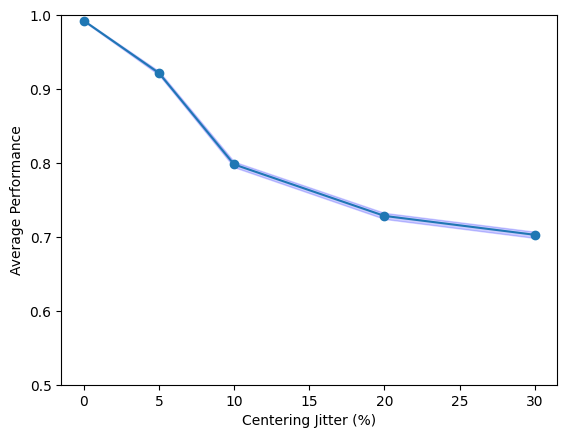

In [34]:
plt.figure()
plt.plot(jitt, avg_performance, marker='o')
plt.fill_between(jitt, confidence_interval[:, 0], confidence_interval[:, 1], color='b', alpha=0.2)
plt.ylim(0.5, 1)
plt.xlabel('Centering Jitter (%)')
plt.ylabel('Average Performance')
plt.savefig(f'./figures/Camel_v2_test_nn_jitter_img_perf_trainjitter.png', dpi=300)
plt.savefig(f'./figures/Camel_v2_test_nn_jitter_img_perf_trainjitter.svg', dpi=300)
plt.show()

/mnt/DataDrive3/emeyer/TreeShrewObjectRecognition/5_behaviorModeling/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/mnt/DataDrive3/emeyer/TreeShrewObjectRecognition/5_behaviorModeling/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


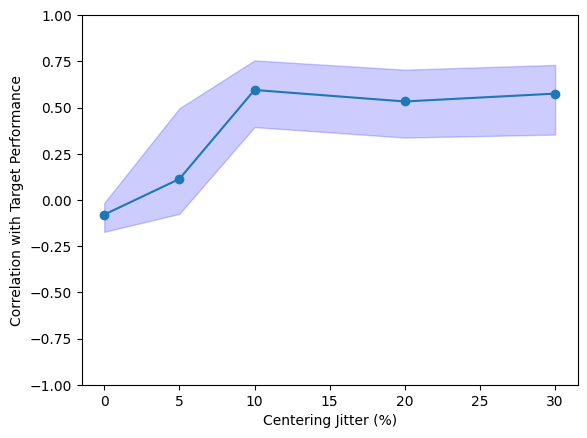

In [35]:
# calculate performance for each target from df['correct']
targ_perf = np.full(len(unique_targs), np.nan)
for t_idx, tt in enumerate(unique_targs):
    targ_idx = df['T_Expt_ID'] == tt
    targ_perf[t_idx] = np.mean(df.loc[targ_idx, 'correct'])

# for each jitter level, compute correlation between targ_correct and targ_perf with bootstrapping and plotting the results
corr = np.full(len(jitt), np.nan)
boot_corr = np.full((len(jitt), 1000), np.nan)
for jj in range(len(jitt)):
    corr[jj] = np.corrcoef(targ_correct[jj,:], targ_perf)[0, 1]
    for b in range(1000):
        boot_idx = np.random.choice(len(unique_targs), len(unique_targs), replace=True)
        boot_corr[jj,b] = np.corrcoef(targ_correct[jj,boot_idx], targ_perf[boot_idx])[0, 1]

plt.figure()
plt.plot(jitt, corr, marker='o')
plt.fill_between(jitt, np.nanpercentile(boot_corr, 2.5, axis=1), np.nanpercentile(boot_corr, 97.5, axis=1), color='b', alpha=0.2)
plt.xlabel('Centering Jitter (%)')
plt.ylabel('Correlation with Target Performance')
plt.ylim(-1, 1)
plt.savefig(f'./figures/Camel_v2_test_nn_jitter_img_perf_corr_trainjitt.png', dpi=300)
plt.savefig(f'./figures/Camel_v2_test_nn_jitter_img_perf_corr_trainjitt.svg', dpi=300)
plt.show()

